<h1 style="text-align: center;">Notebook for Fully connected Network</h1>
<p style="text-align: center;">We feed a fully connected network with PCA modes</p>


In [4]:
import numpy as np
import torch
import modred as mr
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import imageio
import os
import POD
import importlib
importlib.reload(POD)

import data_analysis
importlib.reload(data_analysis)

import autoencoder_analysis
importlib.reload(autoencoder_analysis)

import fcnn
importlib.reload(fcnn)

import utils
importlib.reload(utils)

import training
importlib.reload(training)

%matplotlib inline
matplotlib.pyplot.rc('text', usetex=True)

fontsize = 18

from data_analysis import Simulation
current_directory = '../'

In [90]:
from utils import get_freer_gpu

device = get_freer_gpu() if torch.cuda.is_available() else "cpu"

Selected GPU 1 with 47363 MB free memory 


In [97]:
simulation = Simulation(current_directory, normalize = True, Lambda = 0.01)
time_array, x, z, u, w, T, umean, wmean, Tmean = map(lambda x: torch.tensor(x).to(device), simulation.import_data(mean_type = 'Znorm'))
X = np.swapaxes(simulation.X, 0, 1)
h = simulation.h
l = simulation.l


pandey_data = False

if pandey_data:
    simulation = Simulation(current_directory, normalize=True, Lambda=1e-2, Ra=1e7, pandey=pandey_data)
    simulation.import_data_pandey(mean_type="scaled")

data from ..//data/bulk_L0.01_Ra8.npz
X shape (6249, 12393)


# SVD

## in torch

In [18]:
K = 500
X = torch.from_numpy(simulation.X).to(device)
print(f'X shape{X.shape}')
U,S,V = torch.pca_lowrank(X, q=K)
print("SVD")
print(U.shape, S.shape, V.shape)
# U = U.to(torch.float64)
# V = V.to(torch.float64)

X_reconstructed = U @ torch.diag(S) @ torch.conj(V).t()
print(X_reconstructed.shape)

X shapetorch.Size([6249, 12393])
SVD
torch.Size([6249, 500]) torch.Size([500]) torch.Size([12393, 500])
torch.Size([6249, 12393])


In [19]:
from training import compute_nmse
K_values_pca = [1,2,3,5,10,25,50,128,256,500,700, 800, 900,1000,2000,3000,4000, 5000,6249]
NMSE_pca = []

for K in K_values_pca:
    U,S,V = torch.pca_lowrank(X, q=K)
    X_reconstructed = U @ torch.diag(S) @ torch.conj(V).t()
    NMSE_pca.append(compute_nmse_pca(X_reconstructed, X).sum())

In [10]:
def compute_nmse_pca(X_reconstructed, X):

    outputs = X_reconstructed.flatten()
    targets = X.flatten()
    mse = torch.mean((outputs - targets)**2)
    mse_original = torch.mean(targets**2)
    nmse = mse / mse_original
    nmse = nmse.detach().cpu().numpy()

    return nmse

In [2]:
NMSE_pca = [0.6955067022099422,
 0.534258378184433,
 0.4788162951039174,
 0.384012560149645,
 0.2650543192957652,
 0.17675853251165086,
 0.13268473955185145,
 0.0798349404808474,
 0.04811016142633892,
 0.02372146050959682,
 0.014449388602148856,
 0.011468018362941972,
 0.00921345908739675,
 0.007460233096041027,
 0.0015754370770252833,
 0.0007733723048952257,
 0.0006104809422847851,
 0.000581256383121182,
 0.0005772931710731731]

K_values_pca = [1,2,3,5,10,25,50,128,256,500,700, 800, 900,1000,2000,3000,4000, 5000,6249]

In [20]:
NMSE_pca

[0.6872223592519989,
 0.5406564721848462,
 0.46213512684824226,
 0.36860655951323634,
 0.2698023287344537,
 0.17636133100406048,
 0.13258177675411315,
 0.07928162753913238,
 0.04750536863789045,
 0.02312957937104394,
 0.013857930541888256,
 0.010898367339921777,
 0.008629026694814317,
 0.006885160413765728,
 0.0009983674862684192,
 0.0001961793843500785,
 3.3200602808626516e-05,
 3.963277954717714e-06,
 2.165355266044883e-23]

In [ ]:
i = 13
print(NMSE_pca[i], K_values_pca[i])

0.007463056202928463 1000


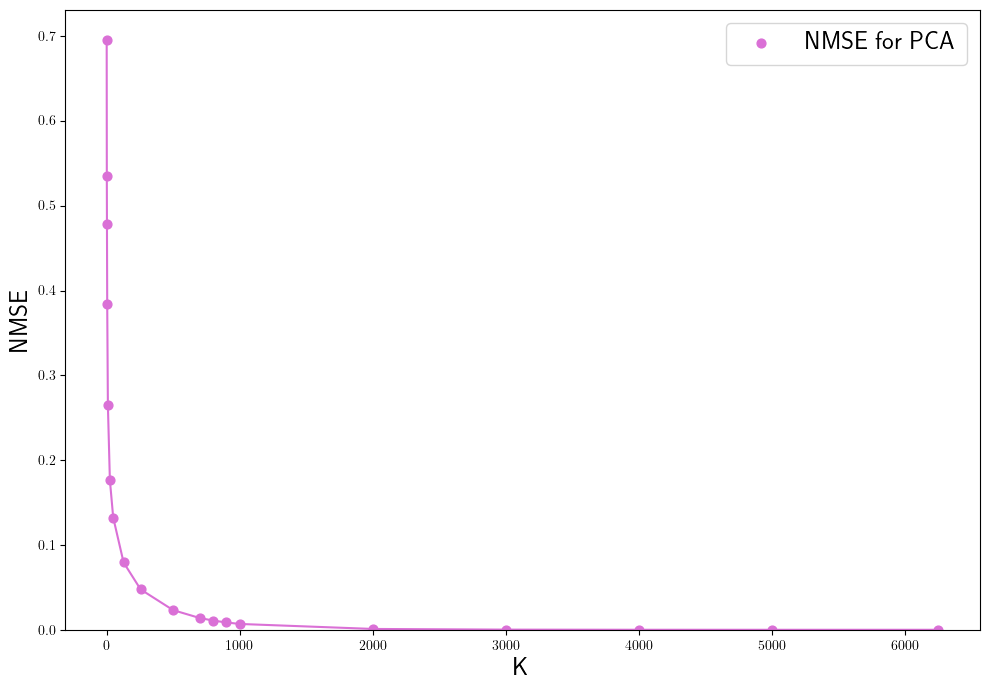

In [5]:
i = 0
j = len(K_values_pca)

fig, ax2 = plt.subplots(figsize = (10, 7)) 
ax2.scatter(K_values_pca[i:j], NMSE_pca[i:j], s = 40, c = 'orchid', label = r"NMSE for PCA")
ax2.plot(K_values_pca[i:j], NMSE_pca[i:j], c = 'orchid', linestyle='-')
# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'K', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# fig.suptitle("On pure RB", fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

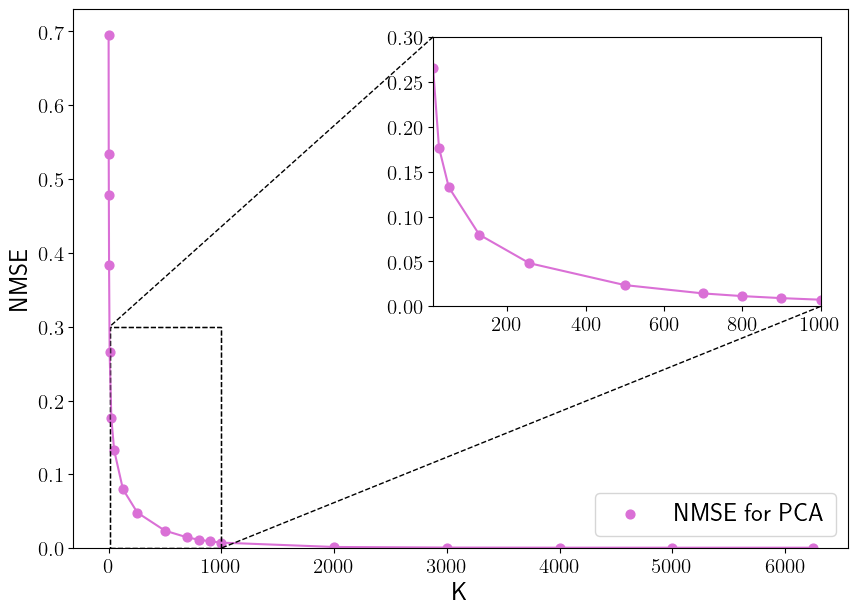

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Your original plot code
i = 0
j = len(K_values_pca)

fig, ax2 = plt.subplots(figsize=(10, 7))
ax2.scatter(K_values_pca[i:j], NMSE_pca[i:j], s=40, c='orchid', label=r"NMSE for PCA")
ax2.plot(K_values_pca[i:j], NMSE_pca[i:j], c='orchid', linestyle='-')
ax2.set_ylabel(r"NMSE", fontsize=fontsize)  # Replace `fontsize` with an actual integer value
ax2.set_xlabel(r'K', fontsize=fontsize)    # Re"ace `fontsize` with an actual integer value
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=fontsize, loc='lower right')  # Replace `fontsize` with an actual integer value

# Adding the zoom-in inset
axins = inset_axes(ax2, width="50%", height="50%", loc='upper right', borderpad=2)

# Specify the region for the zoomed-in plot
x1, x2 = 10, 1000  # Example range for K_values_pca
y1, y2 = 0, 0.3  # Example range for NMSE_pca

axins.scatter(K_values_pca[i:j], NMSE_pca[i:j], s=40, c='orchid')
axins.plot(K_values_pca[i:j], NMSE_pca[i:j], c='orchid', linestyle='-')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
tick_fontsize = 15

ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)
axins.tick_params(axis='both', which='major', labelsize=tick_fontsize)
# Add lines to show the zoomed-in area
ax2.indicate_inset_zoom(axins, edgecolor="black", linestyle="--")
mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="black", linestyle="--")

# Adjust layout
# fig.tight_layout()
plt.show()

## histograms

In [ ]:
Q = 1000
X = torch.from_numpy(simulation.X).to(device)
print(f'X shape{X.shape}')
U,S,V = torch.pca_lowrank(X, q=Q)
# U = torch.from_numpy(U).to(device)
projected_data = U.T @ X
projected_data.cpu()

X shapetorch.Size([12393, 6249])


tensor([[-7.5566e+00, -7.1806e+00, -7.1499e+00,  ..., -3.8107e+00,
         -3.0107e+00, -3.2430e+00],
        [-3.6758e+00, -3.8644e+00, -4.4117e+00,  ..., -9.5542e+00,
         -9.6535e+00, -9.4111e+00],
        [ 1.8050e+00,  2.7859e+00,  3.3848e+00,  ...,  6.5015e+00,
          6.4138e+00,  6.8344e+00],
        ...,
        [-1.9686e-02,  5.9398e-02, -3.1163e-02,  ...,  1.0164e-02,
         -3.1489e-02, -1.4438e-02],
        [-3.2527e-02, -1.1019e-01, -1.4281e-02,  ..., -7.9438e-03,
         -2.6909e-02, -3.4587e-03],
        [-1.2405e-01, -4.3196e-02,  2.2568e-02,  ...,  2.8759e-02,
          6.3780e-04, -6.3892e-02]], dtype=torch.float64)

In [ ]:
print(S[:1000].max(), S[:1000].min(), S[:1000].mean())

tensor(822.0497, device='cuda:0', dtype=torch.float64) tensor(4.8781, device='cuda:0', dtype=torch.float64) tensor(19.9164, device='cuda:0', dtype=torch.float64)


In [ ]:
S.shape

torch.Size([1000])

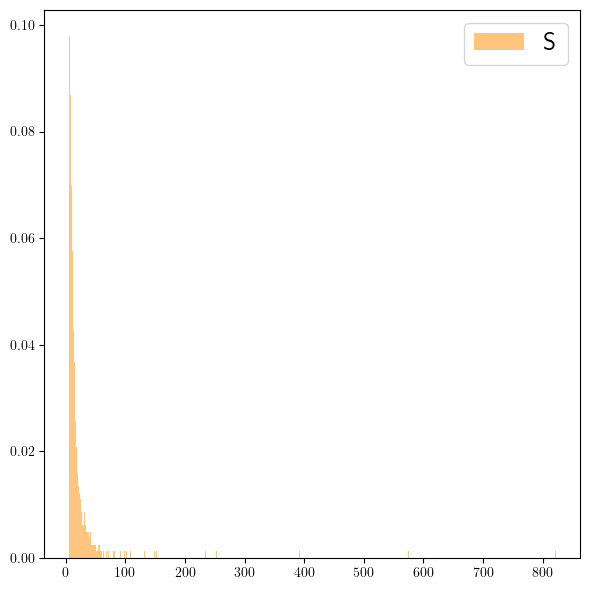

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
# ax.hist(projected_data.cpu().flatten(), bins=100, density=True, alpha=0.5, color='orchid', histtype = 'bar', label = r"projected data")
ax.hist(S.cpu()[:1000].flatten(), bins=1000, density=True, alpha=0.5, color='darkorange', histtype = 'bar', label = r"S")
plt.tight_layout()
plt.legend(fontsize= fontsize)
plt.show()

In [ ]:
def regularisation(projected_data):
    mean = projected_data.mean()
    maximum = abs(projected_data).max()
    projected_data_reg = (projected_data - mean)/maximum
    return projected_data_reg, mean, maximum

In [ ]:
proj_data_reg= regularisation(projected_data)[0]

In [ ]:
proj_data_reg.mean()

tensor(-8.5279e-21, device='cuda:0', dtype=torch.float64)

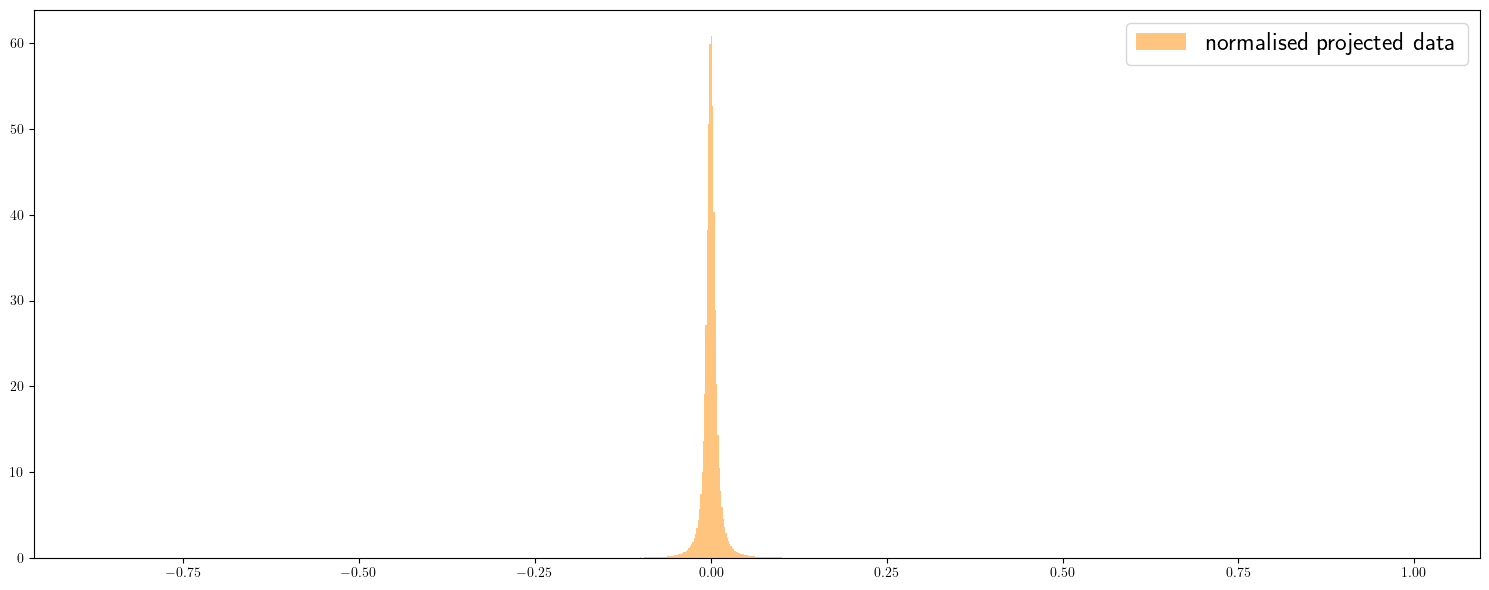

In [ ]:
fig, ax = plt.subplots(figsize = (15,6))
# ax.hist(projected_data.cpu().flatten(), bins=100, density=True, alpha=0.5, color='orchid', histtype = 'bar', label = r"projected data")
ax.hist(proj_data_reg.cpu().flatten(), bins=1000, density=True, alpha=0.5, color='darkorange', histtype = 'bar', label = r"normalised projected data")
plt.tight_layout()
plt.legend(fontsize= fontsize)
plt.show()

In [ ]:
matrice = torch.matmul(proj_data_reg.t(), torch.diag(S))

In [ ]:
matrix = projected_data.t() * 1/(S**0.5)

In [ ]:
matrix = projected_data.t() * 1/torch.sqrt(S)

In [ ]:
projected_data.shape

torch.Size([1000, 6249])

In [ ]:
print(matrix.max(), matrix.min(), matrix.mean())

tensor(0.8192, device='cuda:0', dtype=torch.float64) tensor(-1.0843, device='cuda:0', dtype=torch.float64) tensor(-1.8493e-17, device='cuda:0', dtype=torch.float64)


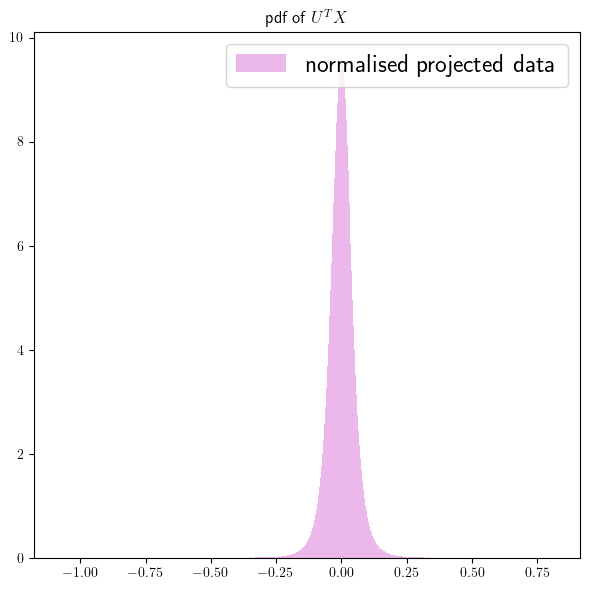

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
# ax.hist(projected_data.cpu().flatten(), bins=100, density=True, alpha=0.5, color='orchid', histtype = 'bar', label = r"projected data")
ax.hist(matrix.cpu().flatten(), bins=1000, density=True, alpha=0.5, color='orchid', histtype = 'bar', label = r"normalised projected data")
# ax.hist(projected_data.cpu().flatten(), bins=1000, density=True, alpha=0.5, color='darkorange', histtype = 'bar', label = r"before normalisation")

ax.set_title(r'pdf of $U^T X$')
plt.tight_layout()
plt.legend(fontsize= fontsize)
plt.show()

# Results from FCNN

date: 2024-06-20 01:49:50.274559
batch_size: 1
size1: (50, 30)
size2: (25, 15)
size3: (13, 8)
size4: (7, 4)
size5: (4, 2)
size6: (2, 1)
Lambda: 0.01
Ra: 100000000.0
lr: 0.0001
kernel_size: 9
weight_decay: 0
execution_time_in_min: 207.67306747436524
group: Ra1e8
wandb_on: True
convnext: True
pandey: True
epoch_1: {'loss': 0.00670196395367384, 'nmse': 17.185305692535685, 'time': 2.124767808119456, 'average_loss': 0.020417434858120375, 'nmse_train': 0.7222474199387527}
epoch_2: {'loss': 0.004736464004963636, 'nmse': 42.544633442162514, 'time': 4.1785701513290405, 'average_loss': 0.011561111002887146, 'nmse_train': 0.4028608837670318}
epoch_3: {'loss': 0.0069601149298250675, 'nmse': 19.25373637456859, 'time': 6.304568815231323, 'average_loss': 0.009569622129242129, 'nmse_train': 0.3358344740093775}
epoch_4: {'loss': 0.008979273959994316, 'nmse': 22.94734950499795, 'time': 8.43103408018748, 'average_loss': 0.008812763004298913, 'nmse_train': 0.31040750511895565}
epoch_5: {'loss': 0.00479517

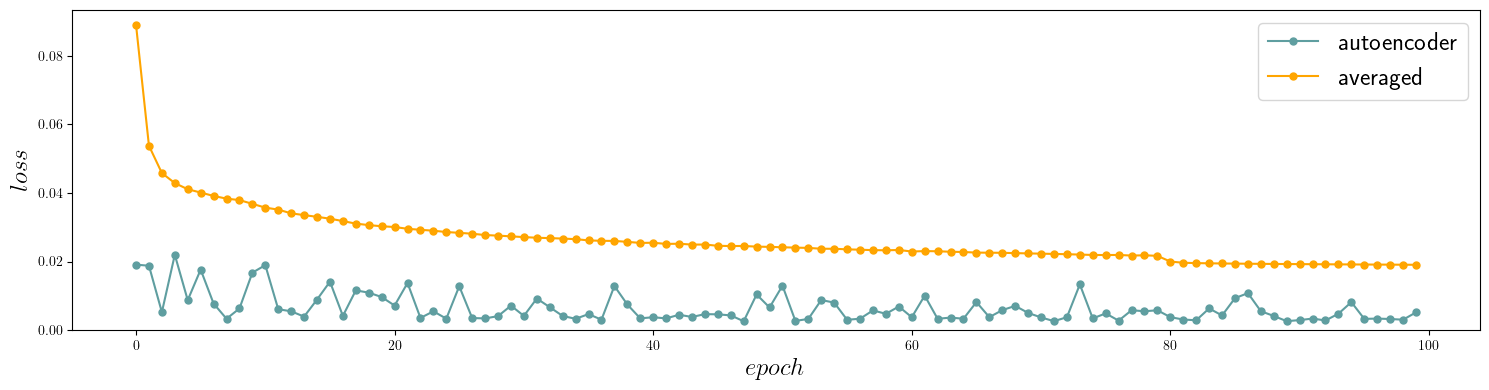

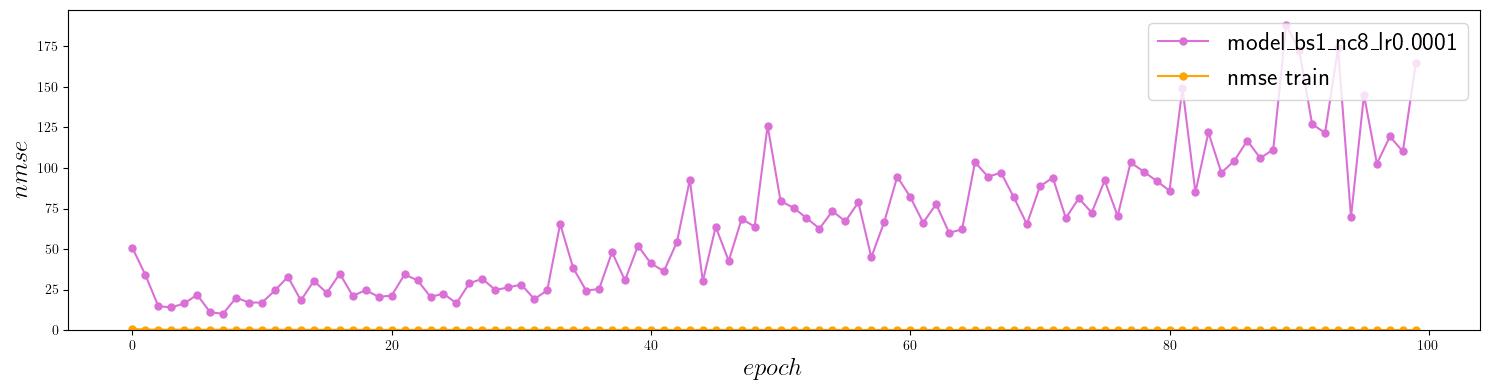

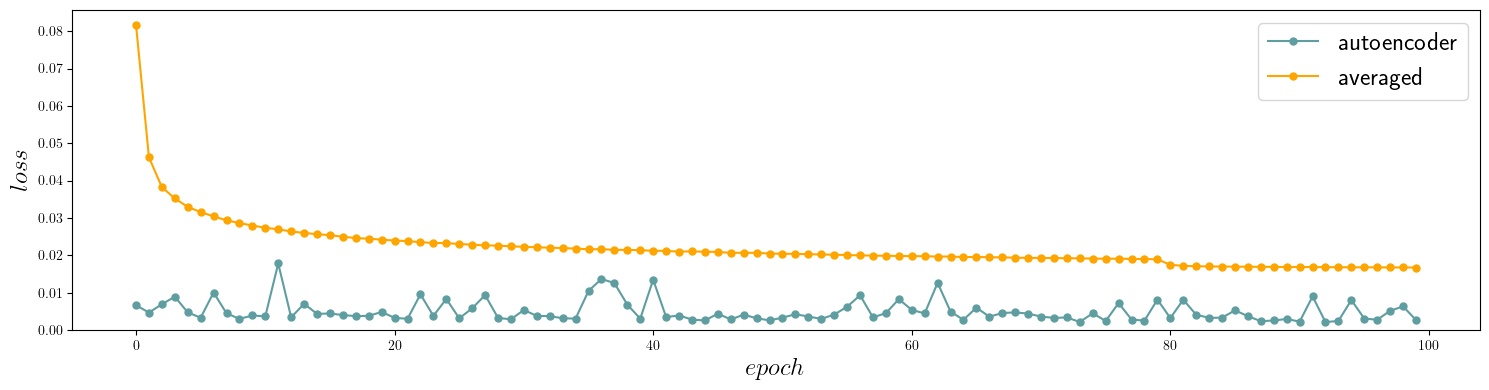

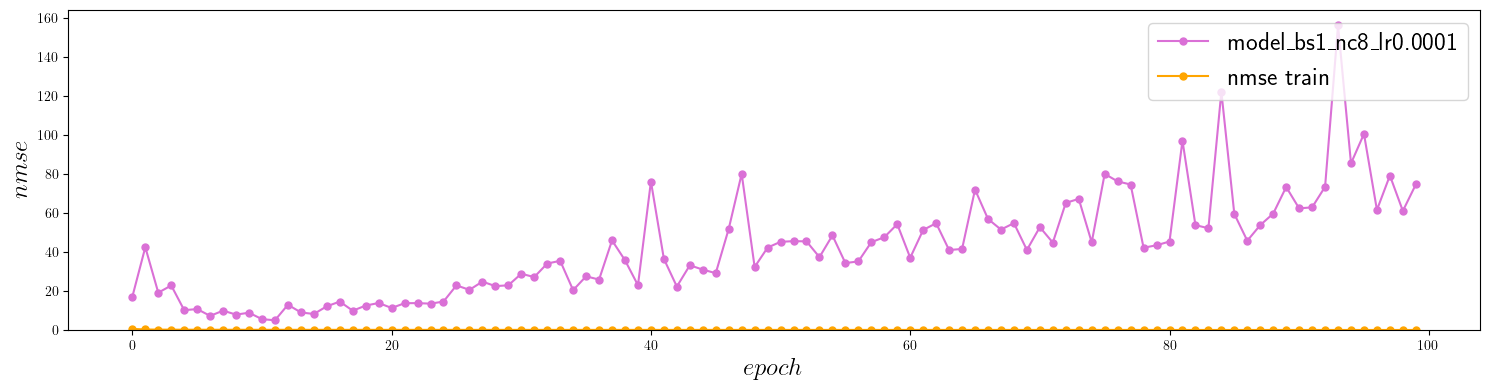

In [81]:
batch_size = 1
K = 128
lr = 1e-4
nc = 8
depth = 4


directory = f'{current_directory}/results/cnn/pandeylike/convnext/Ra1e8/kernel9/'
# directory = f'{current_directory}/results/fcnn/pandey_data/'
# title = f'model_bs{batch_size}_K{K}_lr{lr}'
# title = f'model_K{K}_bs{batch_size}_lr{lr}'
title = f'model_bs{batch_size}_nc{nc}_lr{lr}'

i = 0



from autoencoder_analysis import plot_info_training
plot_info_training(directory, title, i = i)


In [82]:
batch_size = 4

K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000, 2000, 3000, 4000, 5000]
bs_values = [1, 2, 3, 4, 8, 16]
# directory = f'{current_directory}/results/fcnn/new_architecture/pca_only/'



i = 0



from autoencoder_analysis import get_variables_from_info_text
from utils import losses_from_info




nmse_test_9 = []
nmse_train_list_9 = []

plt.ioff()
for i, bs in enumerate(bs_values):
    print(f"K = {K}")
    title = f'model_bs{bs}_nc{nc}_lr{lr}'
    variables, sizes = get_variables_from_info_text(directory, title + '_info.txt')
    epochs, losses, nmse, times, average_loss, nmse_train = losses_from_info(variables)
    nmse_test_9.append(nmse[-1])
    nmse_train_list_9.append(nmse_train[-1])

print(nmse_test_7, nmse_train_list_7)

plt.ion()

K = 128
date: 2024-06-20 01:49:50.274559
batch_size: 1
size1: (50, 30)
size2: (25, 15)
size3: (13, 8)
size4: (7, 4)
size5: (4, 2)
size6: (2, 1)
Lambda: 0.01
Ra: 100000000.0
lr: 0.0001
kernel_size: 9
weight_decay: 0
execution_time_in_min: 207.67306747436524
group: Ra1e8
wandb_on: True
convnext: True
pandey: True
epoch_1: {'loss': 0.00670196395367384, 'nmse': 17.185305692535685, 'time': 2.124767808119456, 'average_loss': 0.020417434858120375, 'nmse_train': 0.7222474199387527}
epoch_2: {'loss': 0.004736464004963636, 'nmse': 42.544633442162514, 'time': 4.1785701513290405, 'average_loss': 0.011561111002887146, 'nmse_train': 0.4028608837670318}
epoch_3: {'loss': 0.0069601149298250675, 'nmse': 19.25373637456859, 'time': 6.304568815231323, 'average_loss': 0.009569622129242129, 'nmse_train': 0.3358344740093775}
epoch_4: {'loss': 0.008979273959994316, 'nmse': 22.94734950499795, 'time': 8.43103408018748, 'average_loss': 0.008812763004298913, 'nmse_train': 0.31040750511895565}
epoch_5: {'loss': 0.

In [85]:
nmse_train_list_

[0.15792334884831974,
 0.14812151872362017,
 0.1522290179239767,
 0.1496449151545987,
 0.16839876526793512,
 0.1696855383198592]

In [43]:
from training import SimuDataset
from torch.utils.data import DataLoader

training_ratio = 0.9

print(f"directory = {directory}")

X = torch.from_numpy(np.swapaxes(simulation.X[: int(training_ratio * simulation.m)], 0, 1)).to(
    device
)
Q = 1000
U, S, V = torch.pca_lowrank(X, q=Q)
# print(U.shape, S.shape, V.shape)
U = U.to(torch.float32)
V = V.to(torch.float32)
S = S.to(torch.float32)



from fcnn import fcnn
from training import test




K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000]
# K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6249]
# K_values = [128]
depth = 4

t_test = int(0.9*simulation.m + 1)
batch_size = 4
lr = 1e-4

test_set = SimuDataset(simulation, device,  rgb = False, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)

whole_set = SimuDataset(simulation, device,  rgb = False, mode = 'whole', training_ratio = 0.9)
whole_loader = DataLoader(dataset = whole_set, batch_size = 4, shuffle = True)

train_set = SimuDataset(simulation, device,  rgb = False, mode = 'train', training_ratio = 0.9)
train_loader = DataLoader(dataset = train_set, batch_size = 4, shuffle = True)


nmse = []
nmse_test = []
nmse_train = []

for i, K in enumerate(K_values):
    title = f'model_K{K}_bs{batch_size}_lr{lr}_info.txt'
    model = fcnn(device = device, U=U, K=K, N=Q, S=S, depth=depth, pca_only=False)
    model.load_state_dict(torch.load(directory + f'model_K{K}_bs{batch_size}_lr{lr}.pt'))
    print(f"K = {K}")
    nmse.append(test(model, whole_loader, device=device, metric = 'nmse'))
    nmse_test.append(test(model, test_loader, device=device, metric = 'nmse'))
    nmse_train.append(test(model, train_loader, device=device, metric = 'nmse'))
    
print(nmse, nmse_test, nmse_train)

directory = ..//results/fcnn/pandey_data/
pandey_data = False
rgb = False
X SHAPE (11201, 19200)
pandey_data = False
rgb = False
X SHAPE (11201, 19200)
pandey_data = False
rgb = False
X SHAPE (11201, 19200)
K = 1
K = 2
K = 3
K = 5
K = 10
K = 25
K = 50
K = 128
K = 256
K = 500
K = 700
K = 800
K = 900
K = 1000
[1.001380819953368, 1.1618940890149319, 0.9727739642724513, 0.7194723846358749, 0.6956101478545669, 0.634380304183335, 0.4697781313999286, 0.43082417219241337, 0.46731694715170546, 0.5191649319832692, 0.498203472200967, 0.45419860325448375, 0.46992724811420966, 0.46368059268775513] [1.0013808191338773, 1.1618940895364258, 0.9727739663690704, 0.7194723850083706, 0.6956101476204266, 0.634380304428118, 0.4697781313839645, 0.4308241722349843, 0.4673169472049192, 0.5191649325287094, 0.4982034722275739, 0.45419860342210683, 0.4699272481860481, 0.46368059312942866] [1.0013808214220656, 1.1618940894246772, 0.9727739650280856, 0.719472384348521, 0.6956101475725344, 0.6343803036671624, 0.4697

In [79]:
K = 128
directory = "..//results/fcnn/new_architecture/pca_only/"
Q = K
from fcnn import fcnn
model = fcnn(device=device, U=U, K=K, N=Q, S=S, depth=depth, pca_only=True)
model.load_state_dict(torch.load(directory + f'model_K_{K}_bs{batch_size}_lr{lr}.pt'))
print(test(model, test_loader, device=device, metric = 'nmse'))

0.013317582722008229


In [44]:
def plot_NMSE(K_values, nmse, nmse_train, nmse_test, title="FCNN", i=0, j=len(K_values), fontsize=18, NMSE_pca=None, K_values_pca=None):
    fig, ax2 = plt.subplots(figsize = (10, 7)) 
    # ax2.scatter(K_values[i:j], nmse[i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data")
    # ax2.plot(K_values[i:j], nmse[i:j], c = 'orchid', linestyle='-')
    ax2.scatter(K_values[i:j], nmse_train[i:j], s = 40, c = 'palegreen', label = r"NMSE for the trained set")
    ax2.plot(K_values[i:j], nmse_train[i:j], c = 'palegreen', linestyle='-')
    ax2.scatter(K_values[i:j], nmse_test[i:j], s = 40, c = 'salmon', label = r"NMSE for the test set")
    ax2.plot(K_values[i:j], nmse_test[i:j], c = 'salmon', linestyle='-')

    ax2.scatter(K_values[i:j], NMSE_pca[i:i + len(K_values[i:j])], s = 40, c = 'orchid', label = r"NMSE for PCA")
    ax2.plot(K_values[i:j], NMSE_pca[i:i + len(K_values[i:j])], c = 'orchid', linestyle='-')
    # ax.set_title(r"Residual norm")
    ax2.set_ylabel(r"NMSE", fontsize = fontsize)
    ax2.set_xlabel(r'K', fontsize = fontsize)
    ax2.set_ylim(bottom = 0)
    # ax2.set_yscale('log') 
    # ax2.set_xscale('log') 
    ax2.legend(fontsize = fontsize)
    ax2.set_ylim(bottom = 0)
    fig.suptitle(title, fontsize = fontsize)
    # fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
    fig.tight_layout()

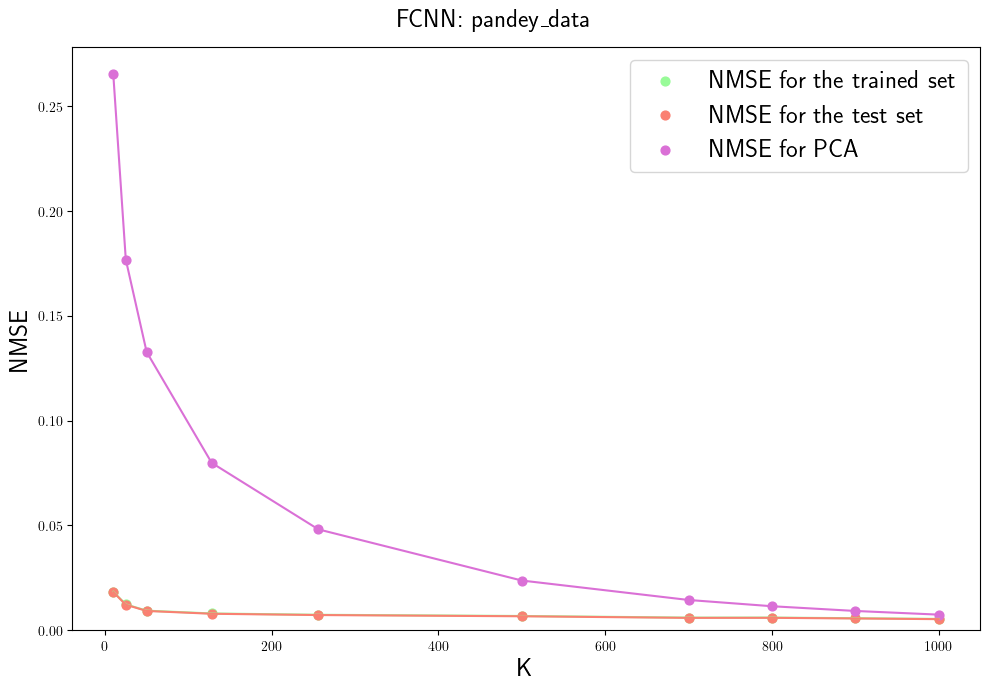

In [54]:
i = 4
j = len(K_values)
plot_NMSE(K_values, nmse, nmse_train_list, nmse_test, title="FCNN: pandey_data", i=i, j=j, NMSE_pca=NMSE_pca, K_values_pca=K_values)

# PCA only

In [48]:
batch_size = 4

K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000, 2000, 3000, 4000, 5000]
K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000]
lr = 1e-4
nc = 64
depth = 4
    
# directory = f'{current_directory}/results/fcnn/new_architecture/pca_only/'



i = 0



from autoencoder_analysis import get_variables_from_info_text
from utils import losses_from_info




nmse_test = []
nmse_train_list = []

plt.ioff()
for i, K in enumerate(K_values):
    print(f"K = {K}")
    title = f'model_K{K}_bs{batch_size}_lr{lr}'
    variables, sizes = get_variables_from_info_text(directory, title + '_info.txt')
    epochs, losses, nmse, times, average_loss, nmse_train = losses_from_info(variables)
    nmse_test.append(nmse[-1])
    nmse_train_list.append(nmse_train[-1])

print(nmse_test, nmse_train_list)

plt.ion()

K = 1
date: 2024-06-19 17:10:47.824611
K: 1
batch_size: 4
Lambda: 0.01
Ra: 10000000.0
thirty_min_epoch: None
num_epoch: 100
depth: 4
lr: 0.0001
weight_decay: 0
execution_time_in_min: 44.00783612330755
Q: 1000
pandey_data: True
wandb_on: True
epoch_1: {'loss': 0.016940850764513016, 'nmse': 1.023052088874396, 'time': 0.44590088923772175, 'average_loss': 0.004153187652759978, 'nmse_train': 1.055142332465401}
epoch_2: {'loss': 0.013986483216285706, 'nmse': 1.0248209260827823, 'time': 0.8936545928319295, 'average_loss': 0.004028900062839785, 'nmse_train': 1.0225165878041664}
epoch_3: {'loss': 0.017348339781165123, 'nmse': 1.0222870689898174, 'time': 1.3410185734430948, 'average_loss': 0.004029237451799245, 'nmse_train': 1.0224953839719513}
epoch_4: {'loss': 0.013138176873326302, 'nmse': 1.0203643790973786, 'time': 1.788539751370748, 'average_loss': 0.004020904138622412, 'nmse_train': 1.0205416071149944}
epoch_5: {'loss': 0.01839633658528328, 'nmse': 1.019390705318049, 'time': 2.236650423208

In [56]:
K_values

[1,
 2,
 3,
 5,
 10,
 25,
 50,
 128,
 256,
 500,
 700,
 800,
 900,
 1000,
 2000,
 3000,
 4000,
 5000]

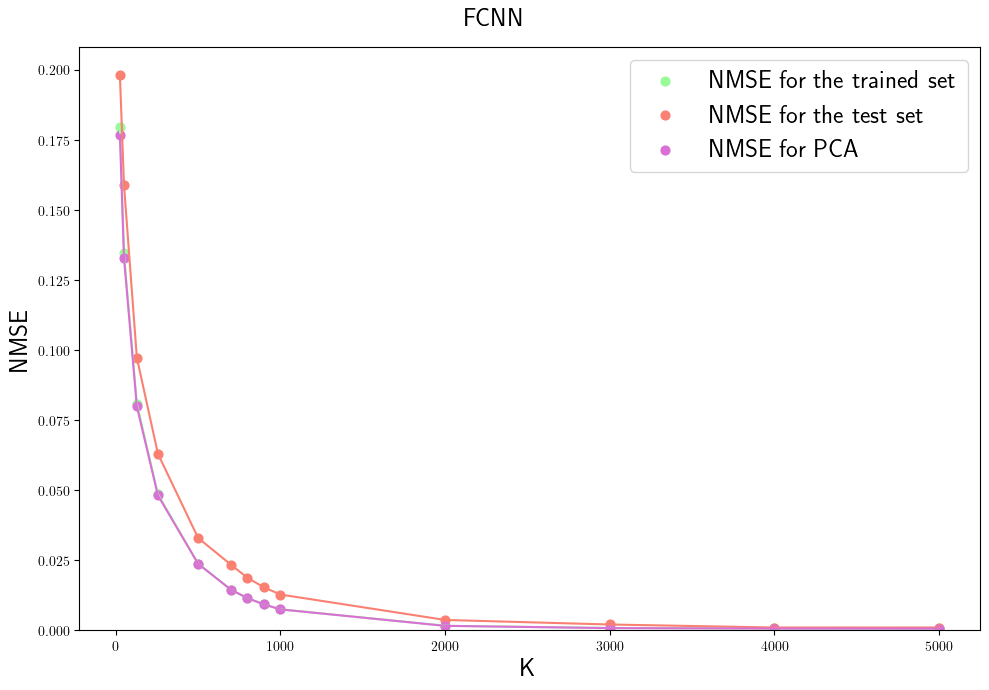

In [13]:
i = 5
j = len(K_values)
plot_NMSE(K_values, nmse, nmse_train_list, nmse_test, title="FCNN", i=i, j=j,  K_values_pca=K_values_pca, NMSE_pca=NMSE_pca)

In [27]:
from training import SimuDataset
from torch.utils.data import DataLoader

training_ratio = 0.9

print(f"directory = {directory}")

X = torch.from_numpy(simulation.X[:, : int(training_ratio * simulation.m)]).to(
    device
)
Q = 1000
U, S, V = torch.pca_lowrank(X, q=Q)
# print(U.shape, S.shape, V.shape)
U = U.to(torch.float32)
V = V.to(torch.float32)
S = S.to(torch.float32)



from fcnn import fcnn
from training import test




K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000]
K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000, 2000, 3000, 4000, 5000]
# K_values = [128]
depth = 0

t_test = int(0.9*simulation.m + 1)
batch_size = 4
lr = 1e-4

test_set = SimuDataset(simulation, device,  rgb = False, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)

whole_set = SimuDataset(simulation, device,  rgb = False, mode = 'whole', training_ratio = 0.9)
whole_loader = DataLoader(dataset = whole_set, batch_size = 4, shuffle = True)

train_set = SimuDataset(simulation, device,  rgb = False, mode = 'train', training_ratio = 0.9)
train_loader = DataLoader(dataset = train_set, batch_size = 4, shuffle = True)


nmse = []
nmse_test = []
nmse_train = []

for i, K in enumerate(K_values):
    title = f'model_K{K}_bs{batch_size}_lr{lr}_info.txt'
    Q = K
    model = fcnn(device = device, U=U, K=K, N=Q, S=S, depth=depth, pca_only=True)
    model.load_state_dict(torch.load(directory + f'model_K_{K}_bs{batch_size}_lr{lr}.pt'))
    print(f"K = {K}")
    nmse.append(test(model, whole_loader, device=device, metric = 'nmse'))
    nmse_test.append(test(model, test_loader, device=device, metric = 'nmse'))
    nmse_train.append(test(model, train_loader, device=device, metric = 'nmse'))
    
print(nmse, nmse_test, nmse_train)

18

## simple linear

date: 2024-06-11 01:58:49.699662
K: 500
batch_size: 4
Lambda: 0.01
thirty_min_epoch: None
num_epoch: 100
lr: 0.0001
weight_decay: 0
execution_time_in_min: 91.40570791562398
epoch_1: {'loss': 0.005474128294736147, 'nmse': 0.24137296974658967, 'time': 0.953665284315745, 'average_loss': 0.0026797266170872007, 'nmse_train': 0.37256556857446177}
epoch_2: {'loss': 0.0044335732236504555, 'nmse': 0.18463054180145264, 'time': 1.8671199321746825, 'average_loss': 0.001474863726002857, 'nmse_train': 0.20828868729058403}
epoch_3: {'loss': 0.0046156407333910465, 'nmse': 0.14997826755046845, 'time': 2.780063243707021, 'average_loss': 0.001251654327387695, 'nmse_train': 0.17722556645720985}
epoch_4: {'loss': 0.004246861673891544, 'nmse': 0.13849145770072938, 'time': 3.693923310438792, 'average_loss': 0.001112024918267143, 'nmse_train': 0.15778963908468338}
epoch_5: {'loss': 0.0026720536407083273, 'nmse': 0.1315326201915741, 'time': 4.607590166727702, 'average_loss': 0.0010145006713852853, 'nmse_train'

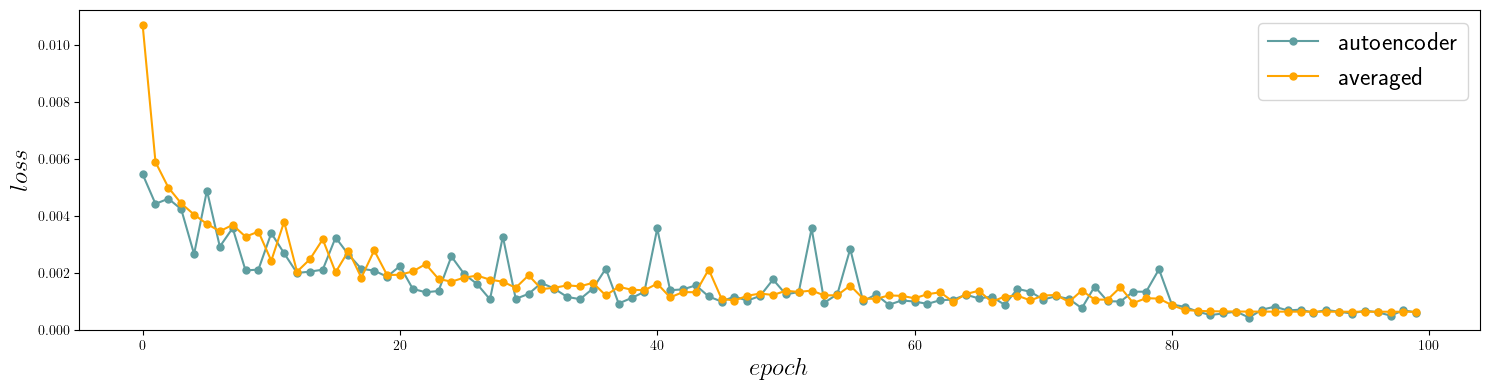

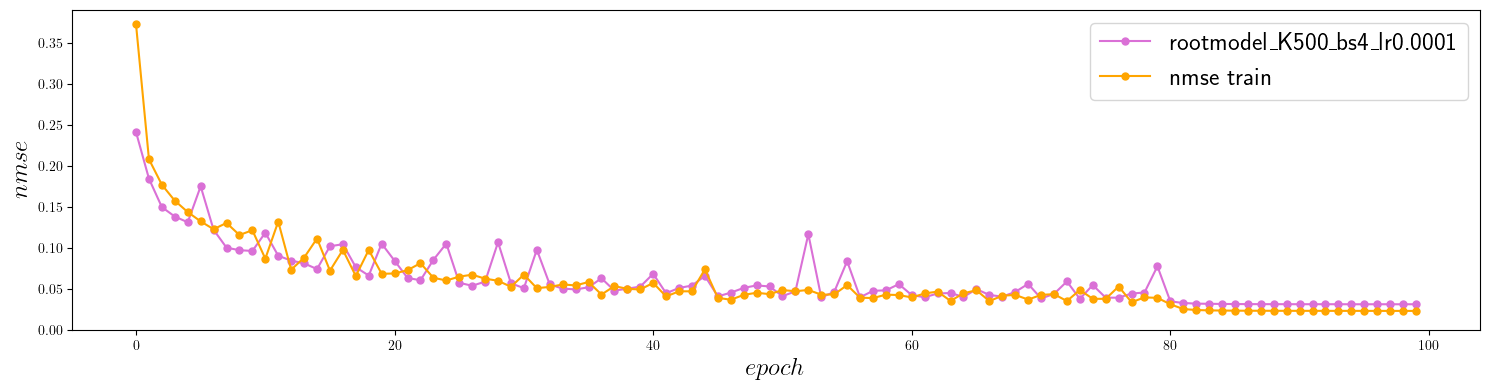

In [18]:
batch_size = 4
K = 500
lr = 1e-4
nc = 64
depth = 4


directory = f'{current_directory}/results/fcnn/simplelinear/'
# directory = f'{current_directory}/results/fcnn/pca_like/'
title = f'model_bs{batch_size}_K{K}_lr{lr}'
title = f'rootmodel_K{K}_bs{batch_size}_lr{lr}'


i = 0



from autoencoder_analysis import plot_info_training
plot_info_training(directory, title, i = i)


In [22]:
from training import SimuDataset
from torch.utils.data import DataLoader

training_ratio = 0.9

print(f"directory = {directory}")
from linear_autoencoder import SimpleLinearAutoencoder
from training import test


N = h * l * 3 

K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000]
K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6249]
# K_values = [128]
depth = 0

t_test = int(0.9*simulation.m + 1)
batch_size = 4
lr = 1e-4

test_set = SimuDataset(simulation, device,  rgb = False, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)

whole_set = SimuDataset(simulation, device,  rgb = False, mode = 'whole', training_ratio = 0.9)
whole_loader = DataLoader(dataset = whole_set, batch_size = 4, shuffle = True)

train_set = SimuDataset(simulation, device,  rgb = False, mode = 'train', training_ratio = 0.9)
train_loader = DataLoader(dataset = train_set, batch_size = 4, shuffle = True)


nmse = []
nmse_test = []
nmse_train = []

for i, K in enumerate(K_values):
    title = f'rootmodel_K{K}_bs{batch_size}_lr{lr}_info.txt'
    model = SimpleLinearAutoencoder(device = device, K=K, N=N)
    model.load_state_dict(torch.load(directory + f'rootmodel_K{K}_bs{batch_size}_lr{lr}.pt'))
    print(f"K = {K}")
    nmse.append(test(model, whole_loader, device=device, metric = 'nmse'))
    nmse_test.append(test(model, test_loader, device=device, metric = 'nmse'))
    nmse_train.append(test(model, train_loader, device=device, metric = 'nmse'))
    
print(nmse, nmse_test, nmse_train)

directory = ..//results/fcnn/simplelinear/
K = 1
K = 2
K = 3
K = 5
K = 10
K = 25
K = 50
K = 128
K = 256
K = 500
K = 700
K = 800
K = 900
K = 1000
K = 2000
K = 3000
K = 4000
K = 5000
K = 6249
[0.6698698521061007, 0.5163892610852557, 0.44898638537949154, 0.36338751053577384, 0.2625962762183848, 0.17785960475451126, 0.1348382972978481, 0.08063081720720808, 0.04831221745617582, 0.023916256063939535, 0.01481650599750505, 0.011900334328217474, 0.009694324614449436, 0.008640216372413556, 0.005837259374786651, 0.006762920433807695, 0.006799767723679304, 0.007723118438762337, 0.006881651373192308] [0.6685621037483215, 0.45406204204559325, 0.40837188091278076, 0.354097314119339, 0.2653326306581497, 0.1988489423751831, 0.15906661274433137, 0.09807845735549926, 0.061773094058036805, 0.033291081634163854, 0.02228038990199566, 0.01857997944056988, 0.015720590978860857, 0.014220402321219443, 0.010184509517997504, 0.011161413955688477, 0.01115987600684166, 0.012120629243552684, 0.010894080021977424] [0

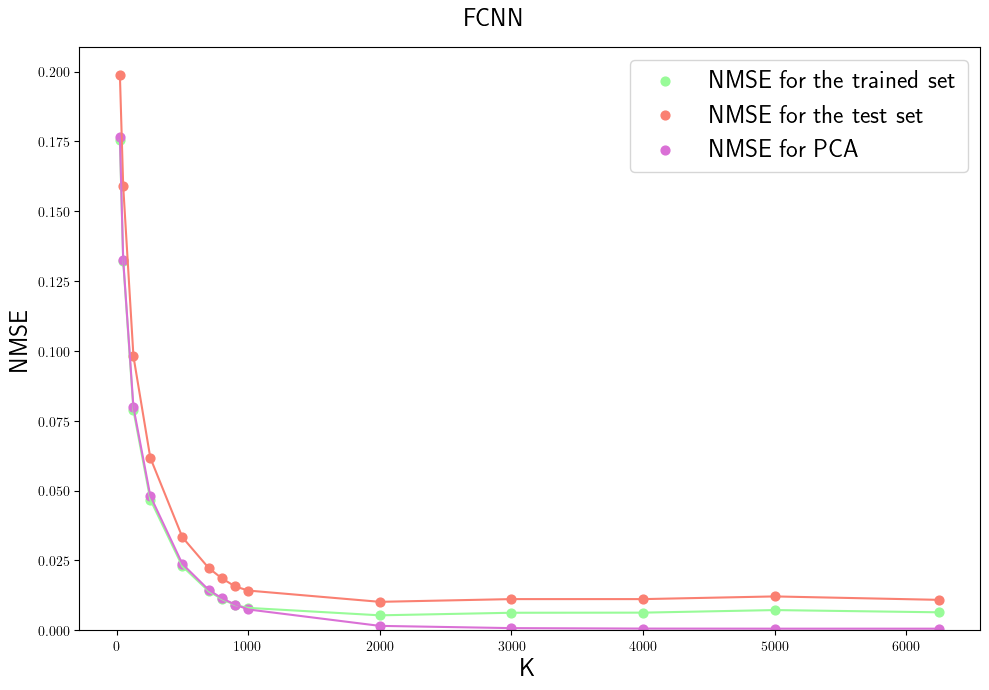

In [23]:
i = 5
j = len(K_values)
plot_NMSE(K_values, nmse, nmse_train, nmse_test, title="FCNN", i=i, j=j,  K_values_pca=K_values_pca, NMSE_pca=NMSE_pca)

# regular saves

In [7]:
batch_size = 4
K = 500
lr = 1e-4
nc = 64
depth = 4


directory = f'{current_directory}/results/fcnn/new_architecture/pca_only/'
# directory = f'{current_directory}/results/fcnn/pca_like/'
title = f'model_bs{batch_size}_K{K}_lr{lr}'

i = 0

from autoencoder_analysis import plot_info_training
plot_info_training(directory, title, i = i)

FileNotFoundError: [Errno 2] No such file or directory: '..//results/fcnn/new_architecture/pca_only/model_bs4_K500_lr0.0001_info.txt'

In [ ]:
variables, sizes = get_variables_from_info_text(directory, title + '_info.txt')

date: 2024-05-22 18:34:37.558802
batch_size: 4
Lambda: 0.01
thirty_min_epoch: None
num_epoch: 100
depth: 4
lr: 0.0001
weight_decay: 0
execution_time_in_min: 15.227439836661022
Q: 1000
epoch_1: {'loss': 0.004804595839232206, 'nmse': 0.2731589770317078, 'time': 0.1522299329439799, 'average_loss': 0.0030142905092139095, 'nmse_train': 0.41541958831324854}
epoch_2: {'loss': 0.006800374947488308, 'nmse': 0.2438265311717987, 'time': 0.3052997787793477, 'average_loss': 0.0018490139873742072, 'nmse_train': 0.2588621594467509}
epoch_3: {'loss': 0.007516126148402691, 'nmse': 0.24168038308620454, 'time': 0.4578228155771891, 'average_loss': 0.001602770518095883, 'nmse_train': 0.22601705677754338}
epoch_4: {'loss': 0.003908364102244377, 'nmse': 0.22195390462875367, 'time': 0.6021280566851298, 'average_loss': 0.0014652456832134893, 'nmse_train': 0.20758080281115868}
epoch_5: {'loss': 0.004498228430747986, 'nmse': 0.2135078191757202, 'time': 0.7457592407862346, 'average_loss': 0.001371800396046608, 'n

[0.2731589770317078, 0.2438265311717987, 0.24168038308620454, 0.22195390462875367, 0.2135078191757202, 0.21408518314361571, 0.2070658767223358, 0.20104235172271728, 0.19902572214603423, 0.1963955283164978, 0.1930757212638855, 0.1905202353000641, 0.18699510991573334, 0.18315434098243713, 0.18341440677642823, 0.1825918114185333, 0.18151957750320435, 0.18000549912452699, 0.17928148984909056, 0.17572906494140625, 0.17347151398658753, 0.17328958749771117, 0.1775294065475464, 0.17256013333797454, 0.17227244794368743, 0.17494945287704466, 0.17156943440437317, 0.17110541224479675, 0.17199130713939667, 0.171689532995224, 0.1679307460784912, 0.1684461849927902, 0.16788538575172424, 0.16768107771873475, 0.16869590878486634, 0.1668502390384674, 0.16595199704170227, 0.16712085783481598, 0.16557698011398314, 0.1687265533208847, 0.16618914008140565, 0.16799190640449524, 0.16632238745689393, 0.16826152682304382, 0.1667587661743164, 0.1682494807243347, 0.16663323163986207, 0.16631014347076417, 0.166143

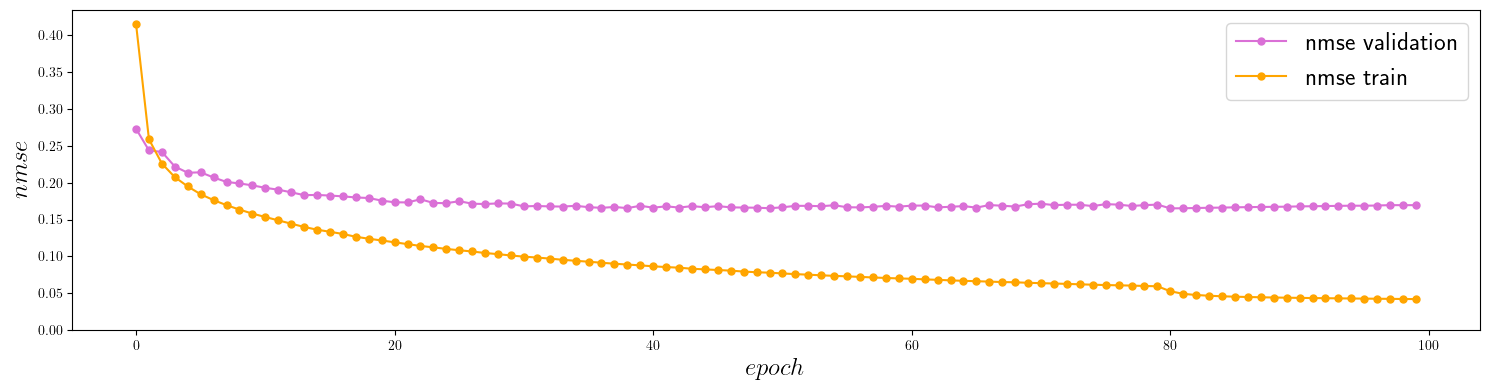

In [ ]:
from utils import losses_from_info
loss = losses_from_info(variables)
epochs, losses, nmse_logs, times, average_loss, nmse_train_logs = loss
print(nmse_logs)


fig, ax1 = plt.subplots(figsize = (15, 4))
ax1.plot(range(len(epochs[i:])), nmse_logs[i:], markersize = 10, marker = '.', c = 'orchid', label = 'nmse validation')
ax1.plot(range(len(epochs[i:])), nmse_train_logs[i:],marker = '.',  markersize = 10, c = 'orange', label = 'nmse train')
# ax1.scatter(range(len(epochs[i:])), nmse_cnn[i:], s = 20, c = 'orange', label = fr"cnn alone, bs = {batch_size}, lr = {lr}")
ax1.set_ylabel(r'$nmse$', fontsize= fontsize)
ax1.set_xlabel(r'$epoch$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper right')
ax1.set_ylim(bottom = 0)



fig.tight_layout()

In [ ]:
from training import SimuDataset
from torch.utils.data import DataLoader

training_ratio = 0.9

directory = f'{current_directory}/results/fcnn/new_architecture/regular_save/'
print(f"directory = {directory}")

X = torch.from_numpy(simulation.X[:, : int(training_ratio * simulation.m)]).to(
    device
)
Q = 1000
U, S, V = torch.pca_lowrank(X, q=Q)
# print(U.shape, S.shape, V.shape)
U = U.to(torch.float32)
V = V.to(torch.float32)
S = S.to(torch.float32)



from fcnn import fcnn
from training import test


K_values = [1, 2, 3, 5, 10, 25, 50, 128, 256, 500, 700, 800, 900, 1000]
t_test = int(0.9*simulation.m + 1)
batch_size = 4
lr = 1e-4

test_set = SimuDataset(simulation, device,  rgb = False, mode = 'test', training_ratio = 0.9)
test_loader = DataLoader(dataset = test_set, batch_size = 4, shuffle = True)

whole_set = SimuDataset(simulation, device,  rgb = False, mode = 'whole', training_ratio = 0.9)
whole_loader = DataLoader(dataset = whole_set, batch_size = 4, shuffle = True)

train_set = SimuDataset(simulation, device,  rgb = False, mode = 'train', training_ratio = 0.9)
train_loader = DataLoader(dataset = train_set, batch_size = 4, shuffle = True)


nmse = []
nmse_test = []
nmse_train = []

for epoch in range(0, 100, 10):
    model = fcnn(device = device, U=U, K = K, N = Q, S = S, depth = depth)
    model.load_state_dict(torch.load(directory + f'model_bs{batch_size}_K{K}_lr{lr}epoch_{epoch}.pt'))
    print(f"epoch = {epoch}")
    nmse.append(test(model, whole_loader, device=device, metric = 'nmse'))
    nmse_test.append(test(model, test_loader, device=device, metric = 'nmse'))
    nmse_train.append(test(model, train_loader, device=device, metric = 'nmse'))
    
print(nmse, nmse_test, nmse_train)

directory = ..//results/fcnn/new_architecture/regular_save/
epoch = 0
epoch = 10
epoch = 20
epoch = 30
epoch = 40
epoch = 50
epoch = 60
epoch = 70
epoch = 80
epoch = 90
[0.385183634257618, 0.32081961668020326, 0.3168385915993538, 0.31739962558104223, 0.322800246457669, 0.3230538827039696, 0.32740430827903105, 0.3290397563368287, 0.3293487239616511, 0.33290529466901975] [0.3842133141040802, 0.33215017595291135, 0.3210499423980713, 0.32301832304000855, 0.3276940720796585, 0.3251087270259857, 0.33146870470046996, 0.33122035598754884, 0.3332662242889404, 0.3370675213813782] [0.3852914663861012, 0.3195604420615463, 0.3163705796300093, 0.3167752153736938, 0.3222563917063717, 0.32282552700675227, 0.32695262730757507, 0.3287974239603893, 0.32891336839068497, 0.33244274230210236]


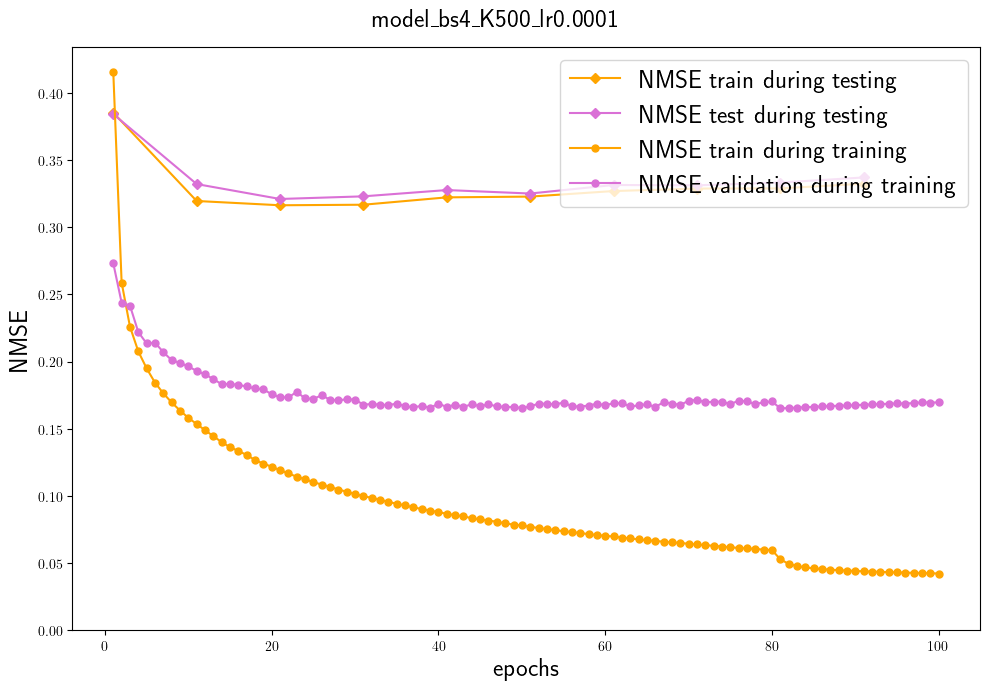

In [ ]:
fig, ax2 = plt.subplots(figsize = (10, 7)) 
ax2.plot(range(1, 101, 10), np.array(nmse_train[i:j]), marker = 'D', markersize = 5, c = 'orange', label = r"NMSE train during testing")
ax2.plot(range(1, 101, 10), nmse_test[i:j], marker = 'D', markersize = 5, c = 'orchid', label = r"NMSE test during testing")
# ax2.plot(range(0, 100, 10), nmse[i:j], marker = '.', markersize = 10, c = 'orchid', label = r"NMSE for the whole set")
ax2.plot(epochs, nmse_train_logs, marker = '.', markersize = 10, c = 'orange', label = r"NMSE train during training")
ax2.plot(epochs, nmse_logs, marker = '.', markersize = 10, c = 'orchid', label = r"NMSE validation during training")

# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'epochs', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# ax2.set_yscale('log') 
# ax2.set_xscale('log') 
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
fig.suptitle(title, fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

In [ ]:
nmse_train_logs

array([0.41541959, 0.25886216, 0.22601706, 0.2075808 , 0.19495624,
       0.18434669, 0.176399  , 0.16958168, 0.16359438, 0.15812761,
       0.15353183, 0.14895241, 0.1444926 , 0.1400528 , 0.13632448,
       0.13349831, 0.13051945, 0.1267163 , 0.12408886, 0.12172293,
       0.11923042, 0.11678011, 0.11430962, 0.1123918 , 0.11028453,
       0.10844729, 0.10679156, 0.10474116, 0.10316201, 0.10138229,
       0.09979124, 0.09860447, 0.0971431 , 0.09554107, 0.09418433,
       0.09294665, 0.0915514 , 0.09021376, 0.08910026, 0.08796634,
       0.08669877, 0.08567654, 0.08483825, 0.08339018, 0.08253564,
       0.08168853, 0.08082887, 0.07957879, 0.07866402, 0.07804847,
       0.07703896, 0.07610197, 0.07535588, 0.07450978, 0.07376364,
       0.07306601, 0.07237211, 0.07157585, 0.07090522, 0.07025165,
       0.0698237 , 0.06897419, 0.06839417, 0.06763409, 0.06702933,
       0.06649783, 0.06597243, 0.06537814, 0.06504929, 0.06435337,
       0.06385537, 0.06336305, 0.06287626, 0.06229838, 0.06177

# GIF

In [ ]:
def apply_fcnn(K, batch_size, U, V, encoded = False):
    from fcnn import fcnn
    autoencoder = fcnn(device = device, U=U, K = K, N = K)
    title = f'model_bs{batch_size}_K{K}_lr{lr}_info.txt'
    autoencoder.load_state_dict(torch.load(directory + f'model_bs{batch_size}_K{K}_lr{lr}.pt'))
    autoencoder.eval() 

    with torch.no_grad():
        encoded_data = autoencoder.encoder(torch.matmul(torch.conj(U).t(), x.t()).t())

    with torch.no_grad():
        decoded_data = autoencoder.decoder(encoded_data)
        decoded_data = torch.matmul(U, decoded_data.t()).t()
    if encoded : 
        return decoded_data, encoded_data
    return decoded_data


decoded_data, encoded_data = apply_fcnn(K, batch_size, U, V, encoded = True)
        # print(f"shape UT {torch.conj(self.U).t().shape}, size xt : {x.t().shape}")

TypeError: fcnn.__init__() missing 1 required positional argument: 'S'

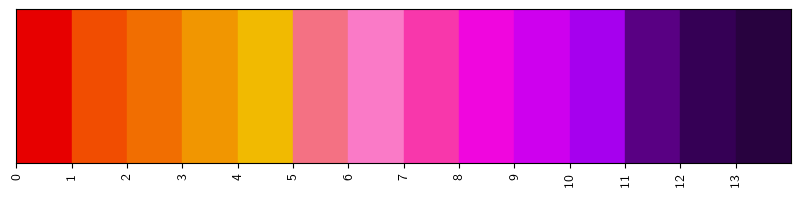

In [ ]:
fig, ax = plt.subplots(figsize=(10, 2))
colormap = ["#E70000", "#F14D01", '#F16E01' , "#F19601", "#F1BA01", "#F47183", "#FA7AC7", "#F837AB", "#F006DE", "#CE00EE",  "#A600EE",  "#590083", "#350055", "#28023f"]
    
# Plot each color in the colormap
for i, color in enumerate(colormap):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))

# Set limits and remove ticks
ax.set_xlim(0, len(colormap))
ax.set_ylim(0, 1)
ax.set_xticks(range(len(colormap)))
ax.set_yticks([])

# Optionally add color labels
ax.set_xticklabels([f'{i}' for i in range(len(colormap))], rotation=90)

# Display the plot
plt.show()

# pandey_data

In [93]:
from data_analysis import Simulation
simulation = Simulation(current_directory, normalize=True, Lambda=1e-2, Ra=1e7, pandey=True)
simulation.import_data_pandey(mean_type="scaled")
X = torch.from_numpy(simulation.X).to(device).to(torch.float32)

In [99]:

X = torch.from_numpy(simulation.X).to(device).to(torch.float32)

In [95]:
def compute_nmse_pca(X_reconstructed, X):

    outputs = X_reconstructed.flatten()
    targets = X.flatten()
    print(outputs.shape, targets.shape)
    mse = torch.mean((outputs - targets)**2)
    # print(f"mse = {mse}")
    mse_original = torch.mean(targets**2)
    nmse = mse / mse_original
    nmse = nmse.detach().cpu().numpy()
    # print(nmse)
    print(f"mse_original = {mse_original}")
    return nmse

In [100]:
K = 16
U,S,V = torch.pca_lowrank(X, q=K)
print(S.shape)
X_reconstructed = U @ torch.diag(S) @ V.t()
print((X-X_reconstructed).mean)
print(X_reconstructed.shape)
print(X_reconstructed.device)
print(X.device)
NMSE_pca = compute_nmse_pca(X_reconstructed, X).sum()
print(f"NMSE_pca = {NMSE_pca}")

torch.Size([16])
<built-in method mean of Tensor object at 0x7f4a500871d0>
torch.Size([6249, 12393])
cuda:1
cuda:1
torch.Size([77443857]) torch.Size([77443857])
mse_original = 0.027853261679410934
NMSE_pca = 0.21224161982536316


In [38]:
from training import compute_nmse
K_values_pca = [1,2,3,5,10,25,50,128,256,500,700, 800, 900,1000,2000,3000,4000, 5000,6249, 10000, 11201]
NMSE_pca = []
for K in K_values_pca:
    U,S,V = torch.pca_lowrank(X, q=K)
    print(S.shape)
    X_reconstructed = U @ torch.diag(S) @ torch.conj(V).t()
    # print(X_reconstructed.shape)
    NMSE_pca.append(compute_nmse_pca(X_reconstructed, X).sum())

torch.Size([1])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([2])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([3])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([5])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([10])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([25])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([50])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([128])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([256])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.015771519392728806
torch.Size([500])
torch.Size([215059200]) torch.Size([215059200])
mse_original = 0.0157715193

In [39]:
NMSE_pca

[0.8397808,
 0.66654605,
 0.57963425,
 0.4806404,
 0.29478014,
 0.12326638,
 0.0658477,
 0.0269837,
 0.010329466,
 0.0028513987,
 0.0012411893,
 0.0008557442,
 0.0006041422,
 0.00043264835,
 2.6054555e-05,
 2.457791e-06,
 2.6530844e-07,
 3.0333553e-08,
 2.1537498e-09,
 2.2370177e-10,
 6.8790923e-06]

In [46]:
i = 
print(NMSE_pca[i], K_values_pca[i])

0.010329466 256


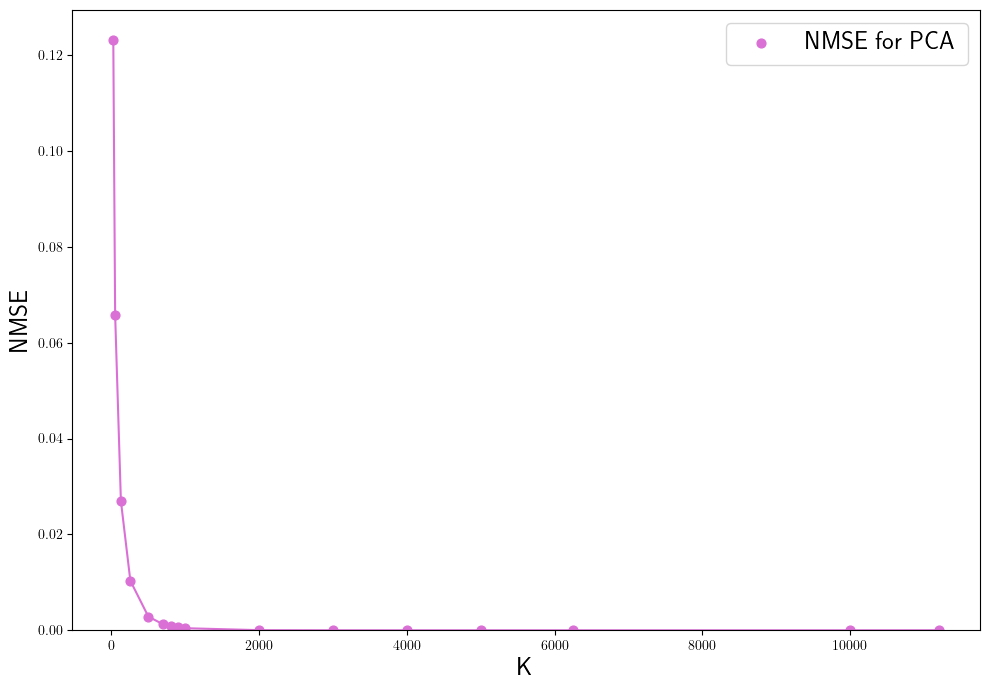

In [42]:
i = 5
j = len(K_values_pca)

fig, ax2 = plt.subplots(figsize = (10, 7)) 
ax2.scatter(K_values_pca[i:j], NMSE_pca[i:j], s = 40, c = 'orchid', label = r"NMSE for PCA")
ax2.plot(K_values_pca[i:j], NMSE_pca[i:j], c = 'orchid', linestyle='-')
# ax.set_title(r"Residual norm")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'K', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# fig.suptitle("On pure RB", fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

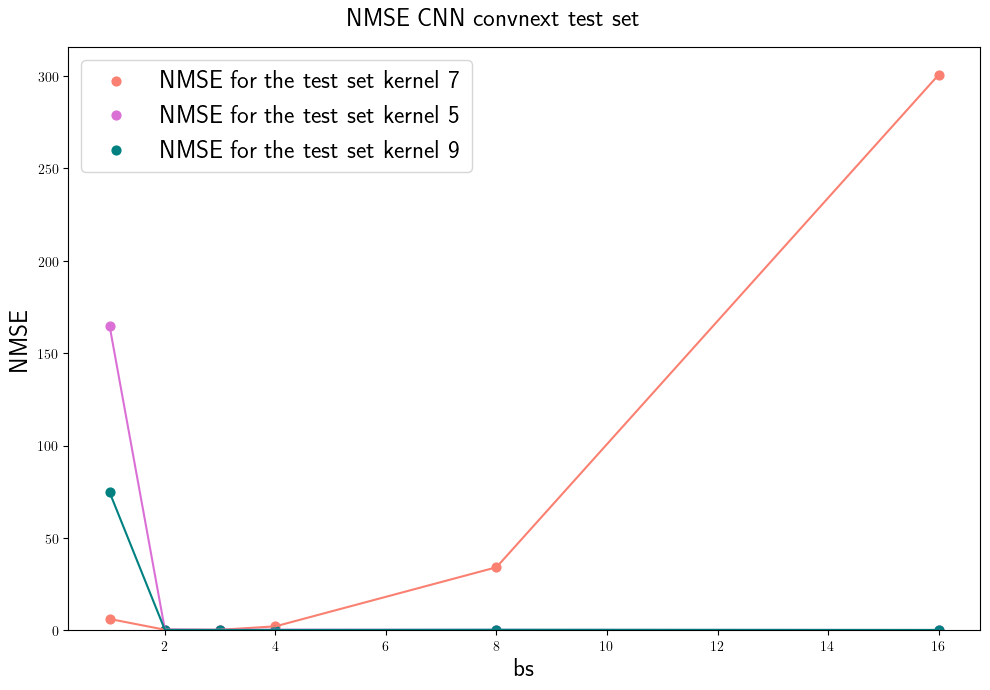

In [88]:
fig, ax2 = plt.subplots(figsize = (10, 7)) 
# ax2.scatter(bs_values[i:j], nmse[i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data")
# ax2.plot(bs_values[i:j], nmse[i:j], c = 'orchid', linestyle='-')

ax2.scatter(bs_values, nmse_test_7, s = 40, c = 'salmon', label = r"NMSE for the test set kernel 7")
ax2.plot(bs_values, nmse_test_7, c = 'salmon', linestyle='-')
ax2.scatter(bs_values, nmse_test_5, s = 40, c = 'orchid', label = r"NMSE for the test set kernel 5")
ax2.plot(bs_values, nmse_test_5, c = 'orchid', linestyle='-')
ax2.scatter(bs_values, nmse_test_9, s = 40, c = 'teal', label = r"NMSE for the test set kernel 9")
ax2.plot(bs_values, nmse_test_9, c = 'teal', linestyle='-')

ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'bs', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# ax2.set_yscale('log') 
# ax2.set_xscale('log') 
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
fig.suptitle("NMSE CNN convnext test set", fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()

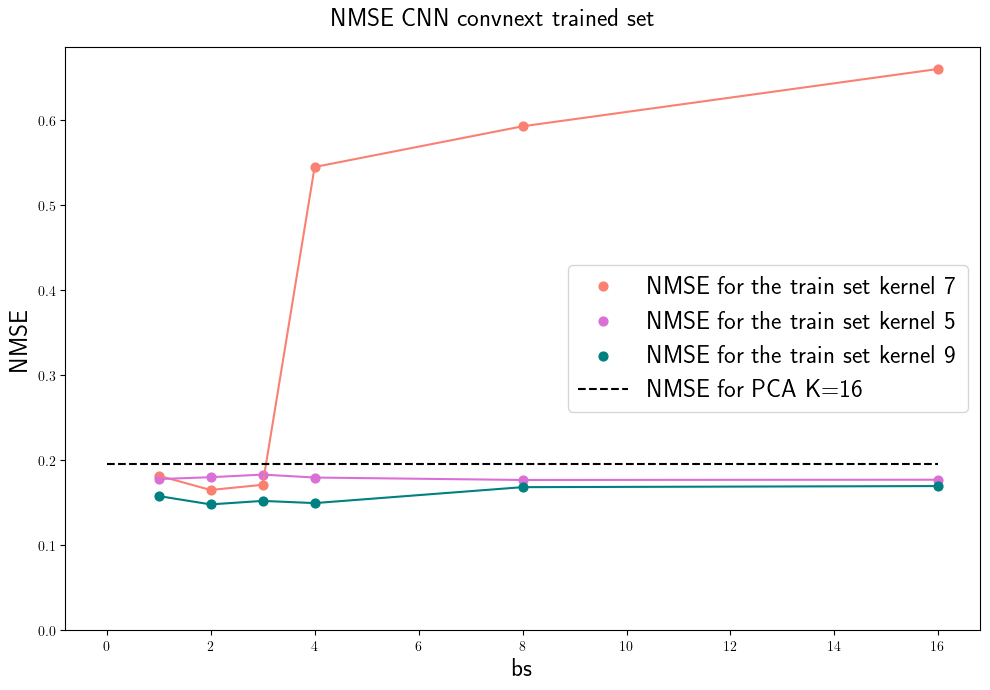

In [101]:
fig, ax2 = plt.subplots(figsize = (10, 7)) 
# ax2.scatter(bs_values[i:j], nmse[i:j], s = 40, c = 'orchid', label = r"NMSE for the whole data")
# ax2.plot(bs_values[i:j], nmse[i:j], c = 'orchid', linestyle='-')

ax2.scatter(bs_values, nmse_train_list_7, s = 40, c = 'salmon', label = r"NMSE for the train set kernel 7")
ax2.plot(bs_values, nmse_train_list_7, c = 'salmon', linestyle='-')
ax2.scatter(bs_values, nmse_train_list_5, s = 40, c = 'orchid', label = r"NMSE for the train set kernel 5")
ax2.plot(bs_values, nmse_train_list_5, c = 'orchid', linestyle='-')
ax2.scatter(bs_values, nmse_train_list_9, s = 40, c = 'teal', label = r"NMSE for the train set kernel 9")
ax2.plot(bs_values, nmse_train_list_9, c = 'teal', linestyle='-')
ax2.hlines(y=0.196, xmin=0, xmax=16, color = 'black', linestyle = '--', label = r"NMSE for PCA K=16")
ax2.set_ylabel(r"NMSE", fontsize = fontsize)
ax2.set_xlabel(r'bs', fontsize = fontsize)
ax2.set_ylim(bottom = 0)
# ax2.set_yscale('log') 
# ax2.set_xscale('log') 
ax2.legend(fontsize = fontsize)
ax2.set_ylim(bottom = 0)
fig.suptitle("NMSE CNN convnext trained set", fontsize = fontsize)
# fig.suptitle(f'number of modes = {num_modes} ', fontsize = fontsize)
fig.tight_layout()